<a href="https://colab.research.google.com/github/JoshEliell/ColabFiles/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Victor Joshua Hernandez Ramon
- **Matrícula:** 274705

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [19]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
media_precio = df['price'].mean()
mediana_precio = df['price'].median()
moda_precio = df['price'].mode()[0] # Usamos [0] para extraer el valor, no la serie

print(f"Media: {media_precio:.2f}")
print(f"Mediana: {mediana_precio:.2f}")
print(f"Moda: {moda_precio}")



Media: 152.72
Mediana: 106.00
Moda: 100


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_  La media y la mediana divergen significativamente. Como vimos en la clase cuando la media es mucho mayor que la mediana, nos sugiere que la distribucion tiene un sesgo positivo. Esto nos dice que que existen valores extremos mas altos (propiedades de Airbnb extremadamente caras) que estan inflando el promedio, mientras que la mediana se mantiene representado mejor el valor central real.

---
## Actividad 2 — Dispersión (20 pts)

In [20]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
rango = df['price'].max() - df['price'].min()
varianza = df['price'].var()
desviacion_std = df['price'].std()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print(f"Rango: {rango}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f}")
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")



Rango: 10000
Varianza: 57674.03
Desviación Estándar: 240.15
Q1: 69.0, Q3: 175.0, IQR: 106.0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_ El rango es enorme debido a que existe al menos una propiedad listada con el valor de 10,000. El IQR (86, que va desde 69 en Q1 hasta 175 en Q3) es mas representativo de la dispersión "típica". El rango se ve arruinado por un solo valor extremadamente alto, mientras que el IQR ignora el 25% mas barato y el 25% mas caro, mostrando de manera confiable cómo varían los precios en el 50% central (los Airbnbs mas comunes).

---
## Actividad 3 — Forma (20 pts)

In [21]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
asimetria = df['price'].skew()
curtosis = df['price'].kurt()

print(f"Asimetría (Skew): {asimetria:.2f}")
print(f"Curtosis (Kurt): {curtosis:.2f}")



Asimetría (Skew): 19.12
Curtosis (Kurt): 585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_  Los valores para price superan los vistos en Income (donde la asimetría era 6.76 y la curtosis 159.6). En este dataset, la asimetria de price (aprox. 19.11) indica una cola derecha extremadamente larga, y su curtosis muy alta (aprox. 585.67) nos dice son muy largas. Con estos valores, esperaria que en la proxima etapa del curso nos enfrentemos a un problema de demasiados datos atipicos. El dataset requiere limpieza antes de que un modelo predictivo pueda usarlo.

---
## Actividad 4 — Visualización (30 pts)

<Axes: ylabel='Frequency'>

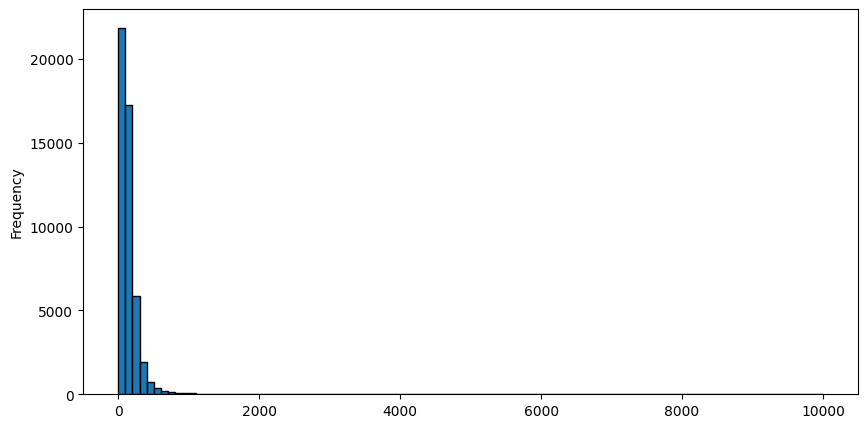

In [22]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.

# Elegi un numero alto de bins (100) porque, debido a la gran cantidad de datos atipicos, si uso pocos bins todo se agrupará en una sola barra inicial
df['price'].plot(kind='hist', bins=100, figsize=(10, 5), edgecolor='black')



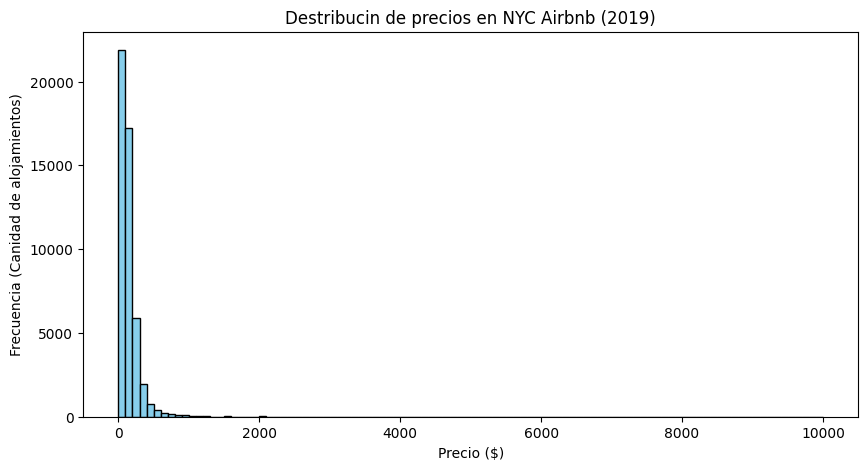

In [23]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=100, color='skyblue', edgecolor='black')
plt.title('Destribucin de precios en NYC Airbnb (2019)')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia (Canidad de alojamientos)')
plt.show()



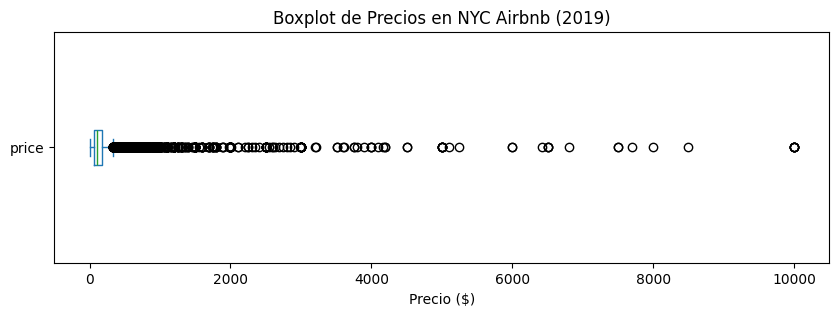

In [24]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
plt.figure(figsize=(10, 3))
df['price'].plot(kind='box', vert=False) # vert=False lo hace horizontal para mejor lectura
plt.title('Boxplot de Precios en NYC Airbnb (2019)')
plt.xlabel('Precio ($)')
plt.show()



**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_ En el histograma, casi todos los datos estan ubicados en la primera y segunda barra, haciendo queno se vean datos mas adelante debido a una larga cola derecha. Los valores atípicos son difíciles de apreciar visualmente ahí. En el diagrama de caja (boxplot), en cambio, los outliers se distinguen mejor. Son una densa línea de puntos negros extendiéndose hacia la derecha. Esto ilustra y confirma de manera visual la asimetría (sesgo derecho) y alta curtosis (picos marcados y colas pesadas) calculadas previamente.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_ Le diria que basarse en el precio promedio de 152.72 es mala idea ya que la media es muy sensible a valores extremos. En lugar de eso, debería fijarse en la mediana, que es de 106, esto significa que la mitad exacta de todos los Airbnb en Nueva York cuestan 106 o menos. Ademas, utilizando el Rango IQR, sabemos que el bloque central fluctúa entre los 69 y los 175 (Q1 a Q3), lo que refleja la realidad que encontraría un turista.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |